In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


In [7]:
train_df = pd.read_csv("/content/mitbih_train.csv",header=None)
test_df = pd.read_csv("/content/mitbih_test.csv",header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


In [9]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
test_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


In [12]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 125.6 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21892 entries, 0 to 21891
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 31.4 MB


In [13]:
train_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
count,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,...,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000
mean,0.890360,0.758160,0.423972,0.219104,0.201127,0.210399,0.205808,0.201773,0.198691,0.196757,...,0.005025,0.004628,0.004291,0.003945,0.003681,0.003471,0.003221,0.002945,0.002807,0.473376
std,0.240909,0.221813,0.227305,0.206878,0.177058,0.171909,0.178481,0.177240,0.171778,0.168357,...,0.044154,0.042089,0.040525,0.038651,0.037193,0.036255,0.034789,0.032865,0.031924,1.143184
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.921922,0.682486,0.250969,0.048458,0.082329,0.088416,0.073333,0.066116,0.065000,0.068639,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.991342,0.826013,0.429472,0.166000,0.147878,0.158798,0.145324,0.144424,0.150000,0.148734,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.910506,0.578767,0.341727,0.258993,0.287628,0.298237,0.295391,0.290832,0.283636,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [14]:
test_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
count,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,...,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000
mean,0.894410,0.761902,0.426627,0.221596,0.201676,0.209891,0.204805,0.200992,0.197634,0.196022,...,0.004588,0.004327,0.004020,0.003789,0.003638,0.003459,0.003166,0.003000,0.002946,0.473689
std,0.234560,0.218659,0.228572,0.208711,0.177727,0.172194,0.177946,0.176142,0.170228,0.166707,...,0.043128,0.042187,0.040255,0.039397,0.038535,0.037717,0.035903,0.035522,0.035266,1.143447
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.924260,0.683366,0.251197,0.050505,0.082873,0.087912,0.072663,0.065997,0.064516,0.068493,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.990431,0.828996,0.432777,0.167630,0.147642,0.158111,0.144068,0.144509,0.150422,0.149029,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.912319,0.583991,0.347092,0.259211,0.287356,0.298453,0.294563,0.289907,0.282956,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.991429,...,0.980392,1.000000,0.966102,1.000000,1.000000,1.000000,1.000000,0.996053,1.000000,4.000000


In [15]:
class_counts = train_df.iloc[:, -1].value_counts().sort_index()

for cls, count in class_counts.items():
    print(f"Class {int(cls)}: {count}")

Class 0: 72471
Class 1: 2223
Class 2: 5788
Class 3: 641
Class 4: 6431


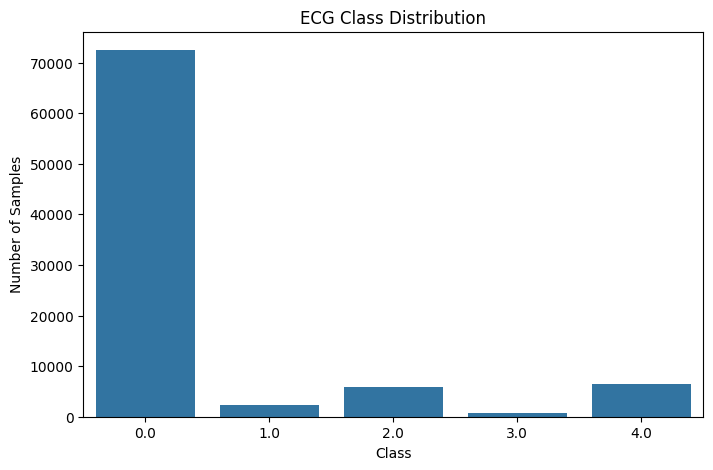

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(x=train_df.iloc[:, -1])

plt.title("ECG Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

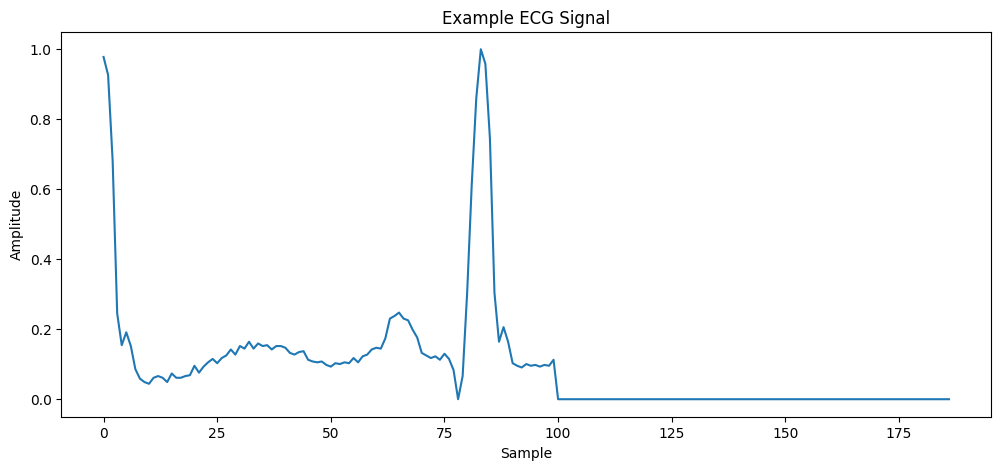

In [17]:
plt.figure(figsize=(12,5))

plt.plot(train_df.iloc[0, :-1])

plt.title("Example ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

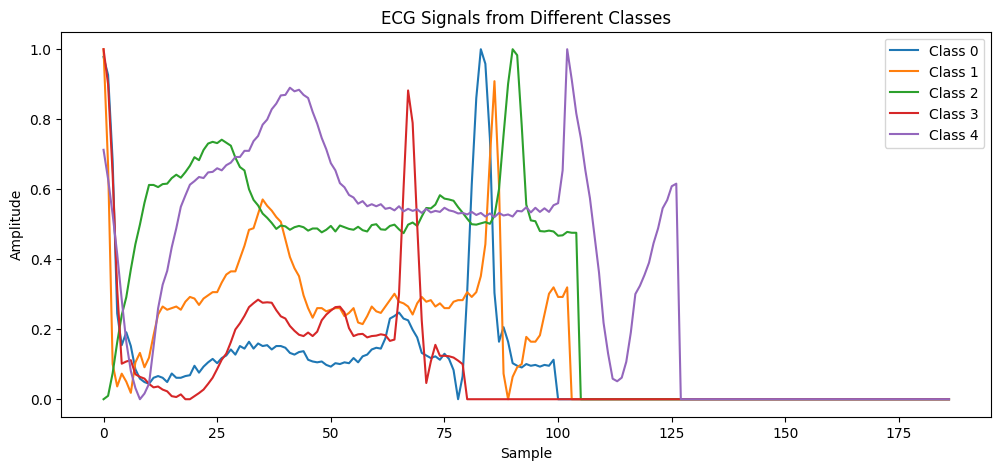

In [18]:
plt.figure(figsize=(12,5))

for class_label in range(5):
    sample = train_df[train_df.iloc[:, -1] == class_label].iloc[0, :-1]
    plt.plot(sample, label=f"Class {class_label}")

plt.title("ECG Signals from Different Classes")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [19]:
print("Missing values in Train:")
print(train_df.isnull().sum().sum())

print("\nMissing values in Test:")
print(test_df.isnull().sum().sum())

Missing values in Train:
0

Missing values in Test:
0


In [20]:
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


In [21]:
train_df = train_df.drop_duplicates()
print("Duplicates removed.")

Duplicates removed.


In [22]:
print("Infinite values in Train:", np.isinf(train_df.select_dtypes(include=np.number)).sum().sum())
print("Infinite values in Test:", np.isinf(test_df.select_dtypes(include=np.number)).sum().sum())

Infinite values in Train: 0
Infinite values in Test: 0


In [23]:
# Separate the features (X) from the target class (y)
# The last column contains the ECG class label [:, -1] only class column
# All previous columns contain the ECG signal features [:, :-1] no class column

X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (87554, 187)
y_train: (87554,)
X_test: (21892, 187)
y_test: (21892,)


In [24]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: [0. 1. 2. 3. 4.]


In [25]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("X_train columns:", X_train.columns[:10].tolist())
print("X_test columns:", X_test.columns[:10].tolist())

print("Same columns:", X_train.columns.equals(X_test.columns))

print("X_train types:")
print(X_train.dtypes.value_counts())

print("X_test types:")
print(X_test.dtypes.value_counts())

X_train shape: (87554, 187)
X_test shape: (21892, 187)
X_train columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
X_test columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Same columns: True
X_train types:
float64    187
Name: count, dtype: int64
X_test types:
float64    187
Name: count, dtype: int64


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


***Modeling***

In [27]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1-Score:", f1_score(y_test, y_pred, average="weighted"))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return y_pred

In [28]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced")

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test)

Accuracy: 0.6739904988123515
Precision: 0.8810875070754816
Recall: 0.6739904988123515
F1-Score: 0.7372153062115616

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.65      0.78     18118
           1       0.14      0.66      0.24       556
           2       0.30      0.73      0.42      1448
           3       0.08      0.87      0.15       162
           4       0.72      0.91      0.81      1608

    accuracy                           0.67     21892
   macro avg       0.44      0.76      0.48     21892
weighted avg       0.88      0.67      0.74     21892



In [29]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = evaluate_model(
    knn_model,
    X_test_scaled,
    y_test)

Accuracy: 0.9727297642974603
Precision: 0.9717655188878505
Recall: 0.9727297642974603
F1-Score: 0.9715585749929384

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     18118
           1       0.89      0.64      0.74       556
           2       0.93      0.89      0.91      1448
           3       0.76      0.64      0.70       162
           4       1.00      0.96      0.98      1608

    accuracy                           0.97     21892
   macro avg       0.91      0.82      0.86     21892
weighted avg       0.97      0.97      0.97     21892



In [30]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = evaluate_model(
    dt_model,
    X_test_scaled,
    y_test
)

Accuracy: 0.9552347889640052
Precision: 0.9548901978189922
Recall: 0.9552347889640052
F1-Score: 0.9550531574880134

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18118
           1       0.68      0.66      0.67       556
           2       0.86      0.86      0.86      1448
           3       0.61      0.59      0.60       162
           4       0.94      0.94      0.94      1608

    accuracy                           0.96     21892
   macro avg       0.81      0.81      0.81     21892
weighted avg       0.95      0.96      0.96     21892



In [31]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight="balanced",n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = evaluate_model(rf_model,X_test_scaled,y_test)

Accuracy: 0.9730038370180888
Precision: 0.9728548879665289
Recall: 0.9730038370180888
F1-Score: 0.9711474340054016

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18118
           1       0.97      0.59      0.73       556
           2       0.98      0.88      0.93      1448
           3       0.82      0.58      0.68       162
           4       1.00      0.94      0.97      1608

    accuracy                           0.97     21892
   macro avg       0.95      0.80      0.86     21892
weighted avg       0.97      0.97      0.97     21892



In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.8790882514160424
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     18118
           1       0.51      0.49      0.50       556
           2       0.44      0.56      0.49      1448
           3       0.22      0.65      0.33       162
           4       0.91      0.89      0.90      1608

    accuracy                           0.88     21892
   macro avg       0.61      0.70      0.63     21892
weighted avg       0.90      0.88      0.89     21892



In [33]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic, average="weighted"),
        precision_score(y_test, y_pred_knn, average="weighted"),
        precision_score(y_test, y_pred_dt, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_svm, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic, average="weighted"),
        recall_score(y_test, y_pred_knn, average="weighted"),
        recall_score(y_test, y_pred_dt, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_svm, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_logistic, average="weighted"),
        f1_score(y_test, y_pred_knn, average="weighted"),
        f1_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.673990,0.881088,0.673990,0.737215
1,KNN,0.972730,0.971766,0.972730,0.971559
2,Decision Tree,0.955235,0.954890,0.955235,0.955053
3,Random Forest,0.973004,0.972855,0.973004,0.971147
4,SVM,0.879088,0.897639,0.879088,0.886884


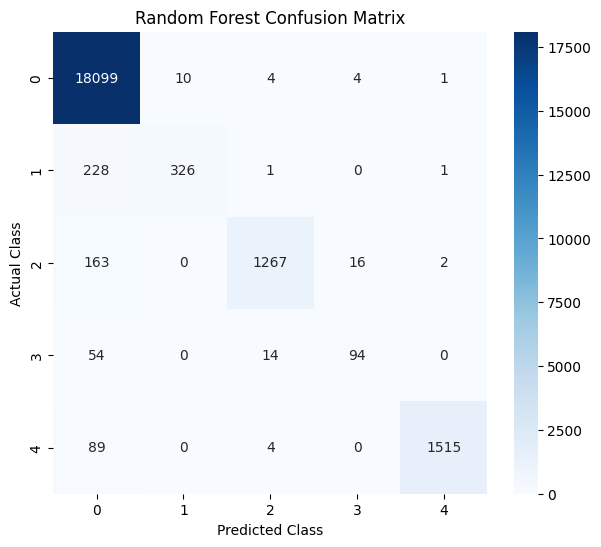

In [34]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 6))
sns.heatmap(cm,annot=True, fmt="d",cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

***Deep Learning***

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, LSTM

from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [36]:
num_classes = len(np.unique(y_train))

y_train_dl = to_categorical(y_train, num_classes)
y_test_dl = to_categorical(y_test, num_classes)

print("Number of classes:", num_classes)
print("y_train_dl shape:", y_train_dl.shape)
print("y_test_dl shape:", y_test_dl.shape)

Number of classes: 5
y_train_dl shape: (87554, 5)
y_test_dl shape: (21892, 5)


In [37]:
nn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

nn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,645 (127.52 KB)

 Trainable params: 32,645 (127.52 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history_nn = nn_model.fit(
    X_train_scaled,
    y_train_dl,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9902 - loss: 0.0324 - val_accuracy: 0.1387 - val_loss: 16.6527
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 1.7032e-04 - val_accuracy: 0.1387 - val_loss: 19.5167
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - loss: 6.0596e-05 - val_accuracy: 0.1387 - val_loss: 21.3263
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - loss: 2.5869e-05 - val_accuracy: 0.1387 - val_loss: 22.6117
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 1.5471e-05 - val_accuracy: 0.1387 - val_loss: 23.7113
Epoch 6/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 1.1584e-05 - val_accuracy: 0.1387 - val_loss: 24.8018
Epoch 7/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - loss: 6.8223e-06 - val_accuracy: 0.1387 - val_loss: 25.7409
Epoch 8/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - 

In [39]:
nn_loss, nn_accuracy = nn_model.evaluate(
    X_test_scaled,
    y_test_dl
)

print("NN Test Accuracy:", nn_accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8276 - loss: 5.7136
NN Test Accuracy: 0.8276082873344421


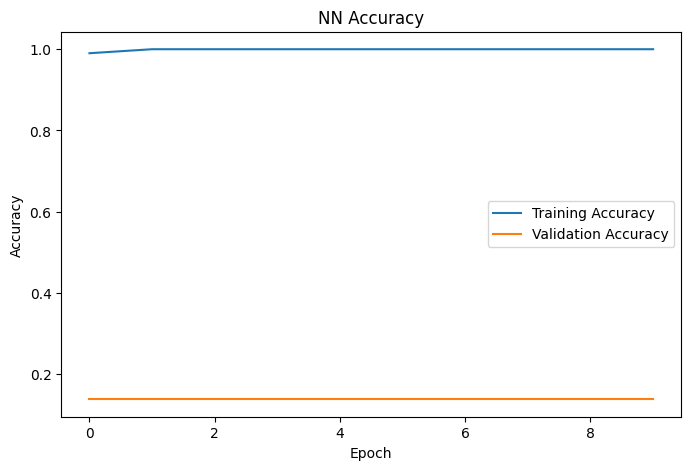

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(history_nn.history["accuracy"], label="Training Accuracy")
plt.plot(history_nn.history["val_accuracy"], label="Validation Accuracy")

plt.title("NN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [41]:
X_train_cnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

print("CNN Train shape:", X_train_cnn.shape)
print("CNN Test shape:", X_test_cnn.shape)

CNN Train shape: (87554, 187, 1)
CNN Test shape: (21892, 187, 1)


In [42]:
cnn_model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_dl,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

Epoch 1/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9984 - loss: 0.0071 - val_accuracy: 0.1387 - val_loss: 23.7817
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 1.0000 - loss: 3.4453e-05 - val_accuracy: 0.1387 - val_loss: 27.2214
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 1.0000 - loss: 1.9595e-05 - val_accuracy: 0.1387 - val_loss: 30.2121
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 1.0000 - loss: 5.0118e-06 - val_accuracy: 0.1387 - val_loss: 31.8539
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 1.0000 - loss: 3.5577e-06 - val_accuracy: 0.1387 - val_loss: 33.4679
Epoch 6/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 1.0000 - loss: 3.4961e-06 - val_accuracy: 0.1387 - val_loss: 35.3102
Epoch 7/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 1.0000 - loss: 1.9466e-06 - val_accuracy: 0.1387 - val_loss: 36.7523
Epoch 8/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - acc

In [44]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test_dl)
print("CNN Test Accuracy:", cnn_accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8276 - loss: 8.3891
CNN Test Accuracy: 0.8276082873344421


In [45]:
X_train_lstm = X_train_cnn.reshape(
    X_train_cnn.shape[0],
    X_train_cnn.shape[1],
    1
)

X_test_lstm = X_test_cnn.reshape(
    X_test_cnn.shape[0],
    X_test_cnn.shape[1],
    1
)

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)

X_train_lstm shape: (87554, 187, 1)
X_test_lstm shape: (21892, 187, 1)


In [48]:
num_classes = y_train_dl.shape[1]

print("Number of classes:", num_classes)


Number of classes: 5


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

lstm_model = Sequential([
    LSTM(
        64,
        input_shape=(X_train_lstm.shape[1], 1)
    ),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(num_classes, activation="softmax")
])

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,381 (83.52 KB)

 Trainable params: 21,381 (83.52 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [51]:
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train_dl,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 128s 230ms/step - accuracy: 0.9976 - loss: 0.0498 - val_accuracy: 0.1387 - val_loss: 12.4545
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 120s 219ms/step - accuracy: 1.0000 - loss: 1.7496e-05 - val_accuracy: 0.1387 - val_loss: 13.0970
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 120s 218ms/step - accuracy: 1.0000 - loss: 6.2310e-06 - val_accuracy: 0.1387 - val_loss: 13.6163
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 121s 221ms/step - accuracy: 1.0000 - loss: 2.2283e-06 - val_accuracy: 0.1387 - val_loss: 14.0807
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 141s 219ms/step - accuracy: 1.0000 - loss: 1.3732e-06 - val_accuracy: 0.1387 - val_loss: 14.4841
Epoch 6/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 149s 232ms/step - accuracy: 1.0000 - loss: 7.8411e-07 - val_accuracy: 0.1387 - val_loss: 14.8302
Epoch 7/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 120s 219ms/step - accuracy: 1.0000 - loss: 5.9962e-07 - val_accuracy: 0.1387 - val_loss: 15.1731
Epoch 8/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 120s 

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [53]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test_lstm,
    y_test_dl
)

print("LSTM Test Accuracy:", lstm_accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8276 - loss: 3.2133
LSTM Test Accuracy: 0.8276082873344421


In [54]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Neural Network",
        "CNN",
        "LSTM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        nn_accuracy,
        cnn_accuracy,
        lstm_accuracy]})
final_results.sort_values(
    by="Accuracy",
    ascending=False)

,Model,Accuracy
3,Random Forest,0.973004
1,KNN,0.972730
2,Decision Tree,0.955235
4,SVM,0.879088
6,CNN,0.827608
5,Neural Network,0.827608
7,LSTM,0.827608
0,Logistic Regression,0.673990


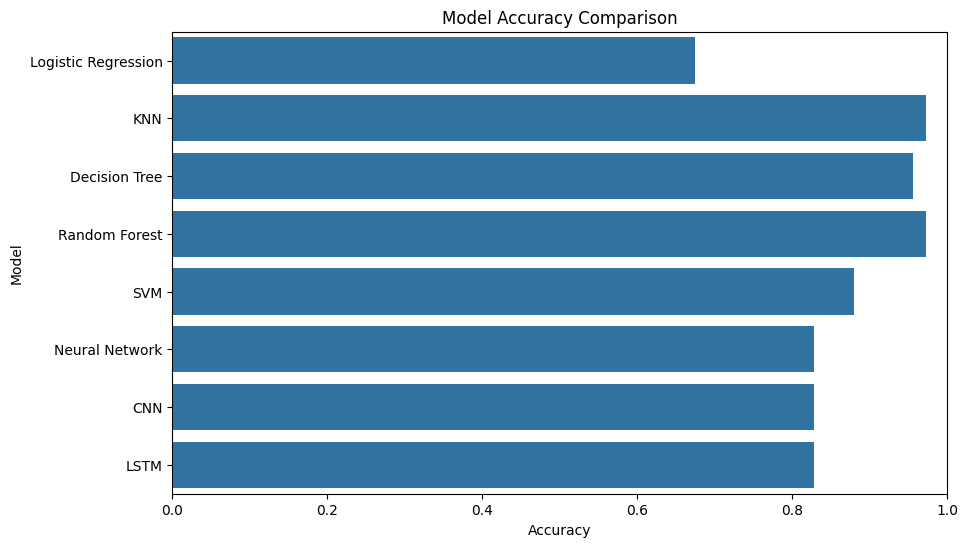

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()

In [57]:
import joblib

joblib.dump(rf_model, "/content/best_ecg_model.pkl")
joblib.dump(scaler, "/content/ecg_scaler.pkl")
joblib.dump(label_encoder, "/content/ecg_label_encoder.pkl")

print("Best ECG model saved successfully!")

Best ECG model saved successfully!
